In [1]:
# --- imports + setup ---
# run this script every time!

import torch
import numpy as np

from controller import LSTMController
from utils import plot_activations, plot_activations_multi
from matplotlib import pyplot as plt

import sys
sys.path.append('..')

from QMC_mouseUSV.subglottal_pressure import subglottal_pressure
from QMC_mouseUSV.glottal_area import glottal_area
from QMC_mouseUSV.impingement_length import impingement_length
from QMC_mouseUSV.jet_speed import jet_speed_from_pressure
from QMC_mouseUSV.USVfreq import USVfreq

# in model.ipynb, add this to your setup/imports cell
import pickle

with open("../data_prep/pkl-files/pca_model.pkl", "rb") as f:
    pca_full = pickle.load(f)

with open("../data_prep/pkl-files/sample_trajectories.pkl", "rb") as f:
    sample_trajectories = pickle.load(f)

print(f"loaded {len(sample_trajectories)} sample trajectories, shape of first:", sample_trajectories[0].shape)

print("loaded pca model, n_components available:", pca_full.n_components_)
print("imports completed!")

loaded 10 sample trajectories, shape of first: (100,)
loaded pca model, n_components available: 100
imports completed!


In [6]:
# --- helper function to prepare a trajectory for input to the model ---
def prepare_example(trajectory, pca_model, pca_dim=10):
    centered = trajectory - trajectory.mean()
    pca_vec = pca_model.transform(centered.reshape(1, -1))[:, :pca_dim]
    pca_vec = torch.tensor(pca_vec, dtype=torch.float32)
    target = torch.tensor(trajectory, dtype=torch.float32).unsqueeze(0)
    return pca_vec, target

# load full contours and build resampled_trajectories for real training
import pickle
from scipy.interpolate import interp1d

with open("../data_prep/pkl-files/sep_14_contours.pkl", "rb") as f:
    contours = pickle.load(f)

def resample_trajectory(freqs, n_points=100):
    if len(freqs) < 2:
        return None
    x_old = np.linspace(0, 1, len(freqs))
    x_new = np.linspace(0, 1, n_points)
    f = interp1d(x_old, freqs, kind="linear")
    return f(x_new)

resampled_trajectories = []
for key, data in contours.items():
    result = resample_trajectory(data["frequency_hz"])
    if result is not None:
        resampled_trajectories.append(result)

print(f"resampled {len(resampled_trajectories)} out of {len(contours)} trajectories")

resampled 19498 out of 19498 trajectories


In [16]:
def prepare_batch(trajectories, pca_model, pca_dim=10):
    trajectories_array = np.array(trajectories)  # shape (batch, 100)
    centered = trajectories_array - trajectories_array.mean(axis=1, keepdims=True)

    pca_vectors = pca_model.transform(centered)[:, :pca_dim]  # ONE call for the whole batch

    pca_vectors = torch.tensor(pca_vectors, dtype=torch.float32)
    targets = torch.tensor(trajectories_array, dtype=torch.float32)

    return pca_vectors, targets

In [ ]:
import time

model = LSTMController(pca_dim=10)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

batch_size = 128 # most optimal efficiency for cpu (should probably be adjusted on gpu)
subset = resampled_trajectories[:100]  # keep testing on 100 first, same as before

start = time.time()

for i in range(0, len(subset), batch_size):
    batch = subset[i:i + batch_size]
    pca_vectors, targets = prepare_batch(batch, pca_full)

    optimizer.zero_grad()
    activations = model(pca_vectors)  # shape (batch, 100, 4) now
    resp_activity, PCAIA_activity, CT_activity, TA_activity = activations[...,0], activations[...,1], activations[...,2], activations[...,3]

    pressure = subglottal_pressure(resp_activity)
    g_area = glottal_area(PCAIA_activity, TA_activity)
    imp_length = impingement_length(CT_activity, TA_activity)
    speed = jet_speed_from_pressure(g_area, pressure)
    predicted_f0 = USVfreq(speed, imp_length)

    loss = torch.sqrt(torch.nn.functional.mse_loss(predicted_f0 / 1000, targets / 1000))
    loss.backward()
    optimizer.step()

elapsed = time.time() - start
print(f"100 trajectories (batched, batch_size={batch_size}) took {elapsed:.2f} seconds")
print(f"estimated time for full dataset (1 epoch): {elapsed / 100 * len(resampled_trajectories) / 60:.2f} minutes")

100 trajectories (batched, batch_size=256) took 0.08 seconds
estimated time for full dataset (1 epoch): 0.25 minutes


epoch 0: avg loss = 10.5145 kHz
epoch 1: avg loss = 9.2562 kHz
epoch 2: avg loss = 9.1296 kHz
epoch 3: avg loss = 9.0970 kHz
epoch 4: avg loss = 9.0949 kHz
epoch 5: avg loss = 9.0462 kHz
epoch 6: avg loss = 9.0496 kHz
epoch 7: avg loss = 9.0466 kHz
epoch 8: avg loss = 9.0361 kHz
epoch 9: avg loss = 9.0122 kHz
epoch 10: avg loss = 8.9883 kHz
epoch 11: avg loss = 8.9858 kHz
epoch 12: avg loss = 8.9865 kHz
epoch 13: avg loss = 9.0285 kHz
epoch 14: avg loss = 9.0306 kHz
epoch 15: avg loss = 9.0304 kHz
epoch 16: avg loss = 9.0382 kHz
epoch 17: avg loss = 9.0012 kHz
epoch 18: avg loss = 8.9813 kHz
epoch 19: avg loss = 9.0307 kHz
epoch 20: avg loss = 9.0210 kHz
epoch 21: avg loss = 9.0150 kHz
epoch 22: avg loss = 9.0154 kHz
epoch 23: avg loss = 9.0142 kHz
epoch 24: avg loss = 8.9973 kHz
epoch 25: avg loss = 9.0261 kHz
epoch 26: avg loss = 8.9873 kHz
epoch 27: avg loss = 9.0021 kHz
epoch 28: avg loss = 8.9756 kHz
epoch 29: avg loss = 8.9826 kHz
epoch 30: avg loss = 8.9836 kHz
epoch 31: avg los

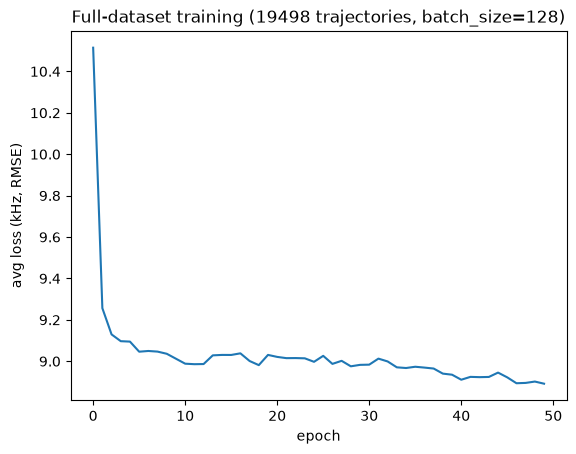

In [18]:
model = LSTMController(pca_dim=10)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

batch_size = 128
epochs = 50

losses = []

for epoch in range(epochs):
    epoch_losses = []
    for i in range(0, len(resampled_trajectories), batch_size):
        batch = resampled_trajectories[i:i + batch_size]
        pca_vectors, targets = prepare_batch(batch, pca_full)

        optimizer.zero_grad()
        activations = model(pca_vectors)
        resp_activity, PCAIA_activity, CT_activity, TA_activity = activations[...,0], activations[...,1], activations[...,2], activations[...,3]

        pressure = subglottal_pressure(resp_activity)
        g_area = glottal_area(PCAIA_activity, TA_activity)
        imp_length = impingement_length(CT_activity, TA_activity)
        speed = jet_speed_from_pressure(g_area, pressure)
        predicted_f0 = USVfreq(speed, imp_length)

        loss = torch.sqrt(torch.nn.functional.mse_loss(predicted_f0 / 1000, targets / 1000))
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())

    avg_loss = sum(epoch_losses) / len(epoch_losses)
    losses.append(avg_loss)
    #if epoch % 10 == 0:
    if True:
        print(f"epoch {epoch}: avg loss = {avg_loss:.4f} kHz")

print(f"final avg loss: {losses[-1]:.4f} kHz")

plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("avg loss (kHz, RMSE)")
plt.title(f"Full-dataset training ({len(resampled_trajectories)} trajectories, batch_size={batch_size})")
plt.show()

In [15]:
# ------------- don't run anything below here, just keep for reference -------------

epoch 0: loss = 18.66196 kHz
epoch 20: loss = 3.52798 kHz
epoch 40: loss = 0.98461 kHz
epoch 60: loss = 0.42107 kHz
epoch 80: loss = 0.42057 kHz
epoch 100: loss = 0.40506 kHz
epoch 120: loss = 0.40019 kHz
epoch 140: loss = 0.39594 kHz
epoch 160: loss = 0.39162 kHz
epoch 180: loss = 0.38701 kHz
epoch 200: loss = 0.38214 kHz
epoch 220: loss = 0.37702 kHz
epoch 240: loss = 0.37167 kHz
epoch 260: loss = 0.36610 kHz
epoch 280: loss = 0.36033 kHz
final loss: 0.35 kHz


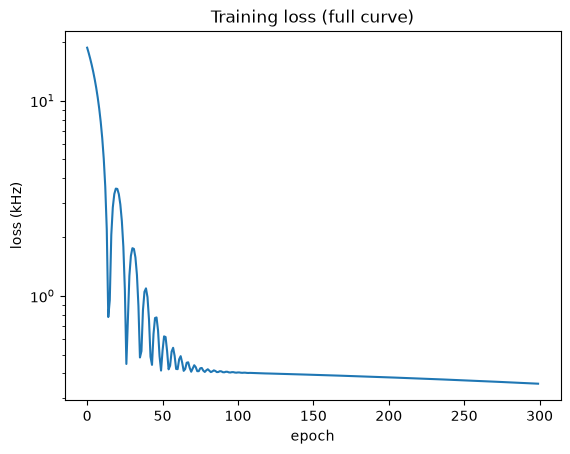

predicted f0 range:96542.2890625 - 99511.75 Hz
target f0 range:99257.8125 - 99609.375 Hz
beta range: 0.5591141581535339 0.5645471215248108


In [9]:
model = LSTMController(pca_dim=10)

# --- training loop with completely synethetic target f0 ---

# lr = 1e-2 works well w MSE loss @ 300 epochs
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

real_trajectory = sample_trajectories[0]
real_trajectory_centered = real_trajectory - real_trajectory.mean()
real_pca_vector = pca_full.transform(real_trajectory_centered.reshape(1, -1))[:, :10]
pca_vector = torch.tensor(real_pca_vector, dtype=torch.float32)

real_target_f0 = torch.tensor(real_trajectory, dtype=torch.float32).unsqueeze(0)

losses = []

for epoch in range(300):
    optimizer.zero_grad()

    activations = model(pca_vector)
    resp_activity = activations[..., 0]
    PCAIA_activity = activations[..., 1]
    CT_activity = activations[..., 2]
    TA_activity = activations[..., 3]

    pressure = subglottal_pressure(resp_activity)
    g_area = glottal_area(PCAIA_activity, TA_activity)
    imp_length = impingement_length(CT_activity, TA_activity)
    speed = jet_speed_from_pressure(g_area, pressure)
    predicted_f0 = USVfreq(speed, imp_length)

    predicted_f0_khz = predicted_f0 / 1000
    target_f0_khz = real_target_f0 / 1000
    loss = torch.sqrt(torch.nn.functional.mse_loss(predicted_f0_khz, target_f0_khz))

    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    if epoch % 20 == 0:
        print(f"epoch {epoch}: loss = {loss.item():.5f} kHz")

print(f"final loss: {losses[-1]:.2f} kHz")

# graph loss over time
plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("loss (kHz)")
plt.yscale("log")  # helpful when values span multiple orders of magnitude
plt.title("Training loss (full curve)")
plt.show()

# check the mucsle activations after training
with torch.no_grad():
    activations_start_check = model(pca_vector)
    pred_check = USVfreq(
        jet_speed_from_pressure(
            glottal_area(activations_start_check[...,1], activations_start_check[...,3]),
            subglottal_pressure(activations_start_check[...,0])
        ),
        impingement_length(activations_start_check[...,2], activations_start_check[...,3])
    )
    print("predicted f0 range:" + str(pred_check.min().item()) + " - " + str(pred_check.max().item()) + " Hz")
    print("target f0 range:" + str(real_target_f0.min().item()) + " - " + str(real_target_f0.max().item()) + " Hz")

    g_area_check = glottal_area(activations_start_check[...,1], activations_start_check[...,3])
    tracheal_diameter = 2 * torch.sqrt(torch.tensor(0.95e-6) / torch.pi)
    glottal_diameter = 2 * torch.sqrt(g_area_check / torch.pi)
    beta_check = glottal_diameter / tracheal_diameter
    print("beta range:", beta_check.min().item(), beta_check.max().item())

In [9]:
# get one real pca vector working

with open("../data_prep/pkl-files/sample_trajectories.pkl", "rb") as f:
    sample_trajectories = pickle.load(f)

print(f"Loaded {len(sample_trajectories)} sample trajectories, shape of first:", sample_trajectories[0].shape)

Loaded 10 sample trajectories, shape of first: (100,)
